# This notebook includes a demo implementation of simple linear regression to a toy dataset.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("placement.csv")
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


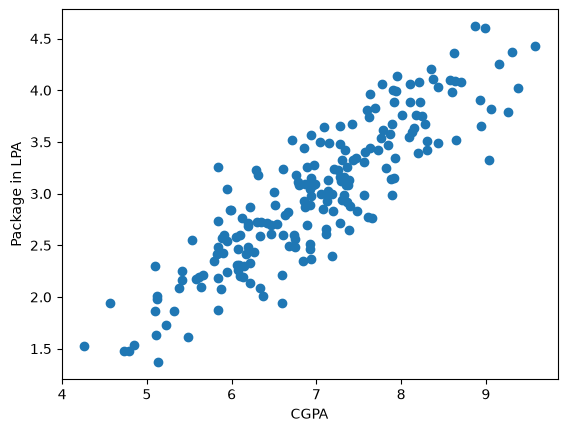

In [17]:
plt.scatter(x=df['cgpa'],y=df['package'])
plt.xlabel("CGPA")
plt.ylabel("Package in LPA")
plt.show()

In [3]:
X = df.iloc[:,0]
y = df.iloc[:,-1]

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
X_test.shape

(40,)

In [6]:
X_train = X_train.values.reshape(-1,1) # reshaped X_train , beacause it contained only 1 column, so was a series instead of a df

In [7]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [8]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.56]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.8961
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[13.47]


In [9]:
lr.coef_ # this gives the slope of the best fit resgression line 

array([0.55795197])

In [10]:
lr.intercept_ # this gives the y-intercept of the best fit regression line

np.float64(-0.8961119222429144)

In [11]:
X_test

112    8.58
29     7.15
182    5.88
199    6.22
193    4.57
85     4.79
10     5.32
54     6.86
115    8.35
35     6.87
12     8.94
92     7.90
13     6.93
126    5.91
174    7.32
2      7.82
44     5.09
3      7.42
113    6.94
14     7.73
23     6.19
25     7.28
6      6.73
134    7.20
165    8.21
173    6.75
45     7.87
65     7.60
48     8.63
122    5.12
178    8.15
64     7.36
9      8.31
57     6.60
78     6.59
71     7.47
128    7.93
176    6.29
131    6.37
53     6.47
Name: cgpa, dtype: float64

In [12]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [26]:
test_value = X_test.iloc[0].reshape(-1,1)

In [ ]:
lr.predict(test_value) # prediction for test value.

array([3.89111601])

In [33]:
y_pred = lr.predict(X_test.values.reshape(-1,1))

In [31]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.780730147510384

Text(0, 0.5, 'Package(in lpa)')

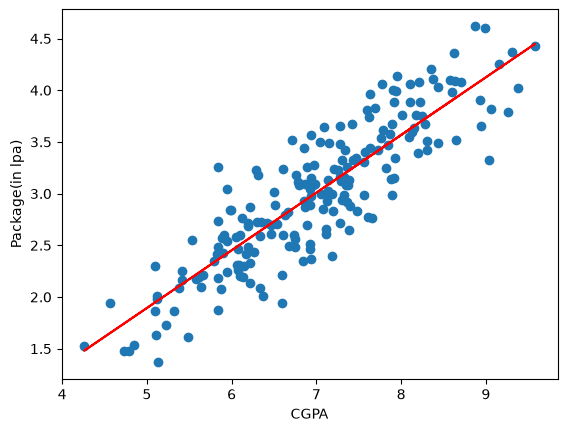

In [40]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [41]:
m = lr.coef_

In [42]:
b = lr.intercept_

In [44]:
y = m* (test_value) + b # this is the equation of regression line
y

array([[3.89111601]])